# DS-A1 Bike Sharing Data Audit

## 1. Introduction

**Question:** How does hourly bike rental volume vary with weather conditions, working-day status, and hour of day in the 2011-2012 Capital Bikeshare data?

This assignment checks the dataset before describing its rental patterns. It uses pandas and matplotlib, with no prediction model. The file contains 17,379 rows and 17 columns. There are no missing values or duplicate date-hour keys. The results describe this dataset and do not show causal effects.

In [1]:
from pathlib import Path
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from either the project folder or the notebooks folder.
root = Path.cwd()
if not (root / "data/raw/hour.csv").exists():
    root = root.parent
results = root / "results"
figures = results / "figures"
figures.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

## 2. Dataset and Provenance

- **Dataset:** Bike Sharing, by Hadi Fanaee-T, UCI Machine Learning Repository.
- **Source:** [UCI dataset page](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset).
- **DOI:** [10.24432/C5W894](https://doi.org/10.24432/C5W894).
- **License:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), as listed by UCI.
- **Download:** [Official archive](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip); downloaded on 2026-09-30.
- **Period:** 2011-01-01 to 2012-12-31, Capital Bikeshare, Washington, D.C.
- **Version:** the downloaded `hour.csv` is identified by the SHA-256 below.

`e03de4ee4ef4dc376ac6e04bf829673c6269e8eba5c60fa121640fa2f829504f`

According to the official `Readme.txt`, Capital Bikeshare system records were aggregated by hour and combined with weather information from Freemeteo. UCI distributes the resulting files. The original CSV is kept unchanged.

Attribution: Fanaee-T, H. (2013), *Bike Sharing*, UCI. The supplied README also requests citation of Fanaee-T and Gama (2013), *Event labeling combining ensemble detectors and background knowledge*, [DOI: 10.1007/s13748-013-0040-3](https://doi.org/10.1007/s13748-013-0040-3).

In [2]:
data_path = root / "data/raw/hour.csv"
actual_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()
assert actual_hash == "e03de4ee4ef4dc376ac6e04bf829673c6269e8eba5c60fa121640fa2f829504f", "The raw file has changed."
print("SHA-256:", actual_hash)
df = pd.read_csv(data_path)
display(df.head())

SHA-256: e03de4ee4ef4dc376ac6e04bf829673c6269e8eba5c60fa121640fa2f829504f


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 3. Research Definitions

| Term | Definition |
|---|---|
| Stakeholder | Capital Bikeshare staff who want to understand rental patterns. |
| Population | Capital Bikeshare system-hours during 2011-2012. |
| Sample | The 17,379 recorded hours in the supplied hourly file. |
| Unit | One recorded hour for the whole system, identified by date and hour. |
| Target | `cnt`: the number of completed rentals in that hour. |
| Estimand | Mean hourly rental count for different weather conditions, working-day status, and hours of the day in the observed 2011-2012 dataset. |

This mean can be written as `E[cnt | weather, workingday, hour]`. The exploratory tables compare averages by hour, working-day status, and weather category.

## 4. Data-Generating Process

```text
Time / weather / calendar
            |
            v
People decide whether to rent a bike
            |
            v
Completed Capital Bikeshare rentals
            |
            v
System records
            |
            v
Hourly aggregated dataset
            |
            v
UCI repository
```

Observed rentals may differ from true demand because a person who wants a bike may not always be able to rent one.

**Provenance lineage:** Capital Bikeshare records + Freemeteo weather -> hourly file prepared by the dataset creator -> UCI archive -> unchanged local `hour.csv` -> this notebook's tables and figures.

## 5. Data Quality Audit

### 5.1 Schema

Inspect the file size, column names, and data types. The expected fields and types come from the official README.

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.dtypes.rename("dtype").to_frame())

Shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,dtype
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [4]:
expected_columns = ["instant", "dteday", "season", "yr", "mnth", "hr",
                    "holiday", "weekday", "workingday", "weathersit",
                    "temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
expected_types = {column: "int64" for column in expected_columns}
expected_types["dteday"] = "object"
for column in ["temp", "atemp", "hum", "windspeed"]:
    expected_types[column] = "float64"
schema_ok = df.columns.tolist() == expected_columns
types_ok = df.dtypes.astype(str).to_dict() == expected_types
print("Expected columns:", schema_ok, "Expected types:", types_ok)

Expected columns: True Expected types: True


The file has 17,379 rows and the expected 17 columns. The column types match the expected schema. `dteday` is initially read as text; it is parsed separately for the month check below.

### 5.2 Range

Check the main ranges listed in the README. The weather measurements are kept in their supplied normalized form.

In [5]:
bounds = {"hr": (0, 23), "mnth": (1, 12), "season": (1, 4),
          "weathersit": (1, 4), "workingday": (0, 1), "holiday": (0, 1),
          "hum": (0, 1), "temp": (0, 1), "atemp": (0, 1), "windspeed": (0, 1)}
invalid_ranges = {}
for column, (low, high) in bounds.items():
    invalid_ranges["invalid " + column + " values"] = int((~df[column].between(low, high)).sum())
invalid_ranges["negative cnt values"] = int((df["cnt"] < 0).sum())
display(pd.Series(invalid_ranges, name="invalid values").to_frame())
month_failures = int((pd.to_datetime(df["dteday"]).dt.month != df["mnth"]).sum())
print("Date/month mismatches:", month_failures)

,invalid values
invalid hr values,0
invalid mnth values,0
invalid season values,0
invalid weathersit values,0
invalid workingday values,0
invalid holiday values,0
invalid hum values,0
invalid temp values,0
invalid atemp values,0
invalid windspeed values,0


Date/month mismatches: 0


All checked values are inside the expected ranges. There are no date/month mismatches. A range check alone does not establish that every measurement is accurate.

### 5.3 Missing Values

In [6]:
missing_by_column = df.isna().sum()
display(missing_by_column.rename("missing values").to_frame())
missing_cells = int(missing_by_column.sum())
print("Total missing cells:", missing_cells)

,missing values
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Total missing cells: 0


No cells are recorded as missing in the supplied file.

### 5.4 Duplicates

In [7]:
exact_duplicates = int(df.duplicated().sum())
key_duplicates = int(df.duplicated(["dteday", "hr"]).sum())
print("Exact duplicates:", exact_duplicates)
print("Duplicate date-hour keys:", key_duplicates)

Exact duplicates: 0
Duplicate date-hour keys: 0


Both duplicate counts are zero.

### 5.5 Anomalies

Inspect minimum and maximum values, the rental-count distribution, and a few hours with the largest counts.

In [8]:
numeric_columns = ["cnt", "casual", "registered", "temp", "atemp", "hum", "windspeed"]
display(df[numeric_columns].describe().round(3))
summary_statistics = df[numeric_columns].agg(["count", "mean", "median", "std"]).T
summary_statistics.index.name = "variable"
summary_statistics.to_csv(results / "summary_statistics.csv")

,cnt,casual,registered,temp,atemp,hum,windspeed
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,189.463,35.676,153.787,0.497,0.476,0.627,0.190
std,181.388,49.305,151.357,0.193,0.172,0.193,0.122
min,1.000,0.000,0.000,0.020,0.000,0.000,0.000
25%,40.000,4.000,34.000,0.340,0.333,0.480,0.104
50%,142.000,17.000,115.000,0.500,0.485,0.630,0.194
75%,281.000,48.000,220.000,0.660,0.621,0.780,0.254
max,977.000,367.000,886.000,1.000,1.000,1.000,0.851


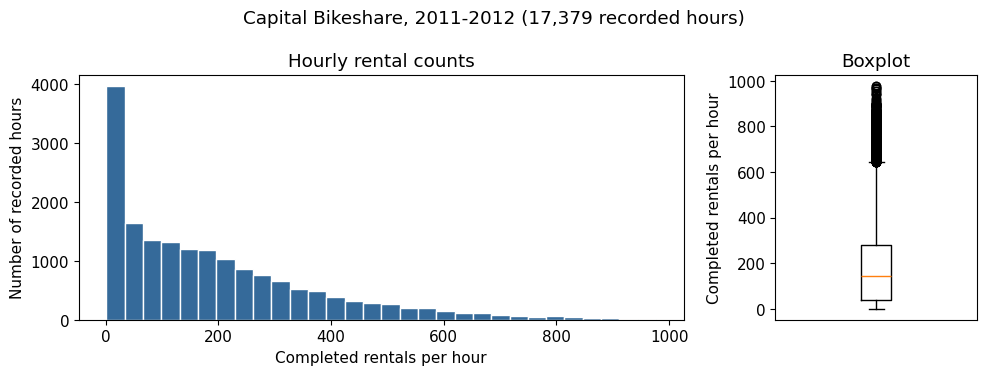

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [3, 1]})
axes[0].hist(df["cnt"], bins=30, color="#356a9a", edgecolor="white")
axes[0].set(title="Hourly rental counts", xlabel="Completed rentals per hour", ylabel="Number of recorded hours")
axes[1].boxplot(df["cnt"])
axes[1].set(title="Boxplot", ylabel="Completed rentals per hour", xticks=[])
fig.suptitle("Capital Bikeshare, 2011-2012 (17,379 recorded hours)")
fig.tight_layout()
fig.savefig(figures / "01_count_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

In [10]:
display(df.nlargest(5, "cnt")[["dteday", "hr", "workingday", "weathersit", "cnt"]])

,dteday,hr,workingday,weathersit,cnt
14773,2012-09-12,18,1,1,977
14964,2012-09-20,17,1,1,976
14748,2012-09-11,17,1,1,970
14725,2012-09-10,18,1,1,968
15084,2012-09-25,17,1,1,967


Rental counts range from 1 to 977 per hour. The histogram has a long right tail, and the boxplot marks some large counts. Large rental counts may represent real peak periods, so they should not automatically be removed as errors. This review does not prove that every record is error-free. No rows are removed.

### 5.6 Leakage

Check whether the two user-count columns reveal the total rental count.

In [11]:
count_identity = (df["cnt"] == df["casual"] + df["registered"]).all()
identity_failures = int((df["cnt"] != df["casual"] + df["registered"]).sum())
print("cnt equals casual + registered on every row:", bool(count_identity))
print("Identity failures:", identity_failures)

cnt equals casual + registered on every row: True
Identity failures: 0


The equality holds on every row. If `cnt` is the prediction target, `casual` and `registered` should not be used as predictors because together they directly reconstruct the target. No prediction model is trained here.

In [12]:
audit_results = {"schema columns match": bool(schema_ok), "schema types match": bool(types_ok),
                 "missing cells": missing_cells, "exact duplicates": exact_duplicates,
                 "duplicate date-hour keys": key_duplicates, **invalid_ranges,
                 "cnt identity failures": identity_failures, "date/month mismatches": month_failures}
pd.DataFrame(audit_results.items(), columns=["check", "result"]).to_csv(
    results / "audit_results.csv", index=False)

## 6. Exploratory Analysis

The following averages describe recorded hours in this dataset.

### 6.1 Rentals by Hour

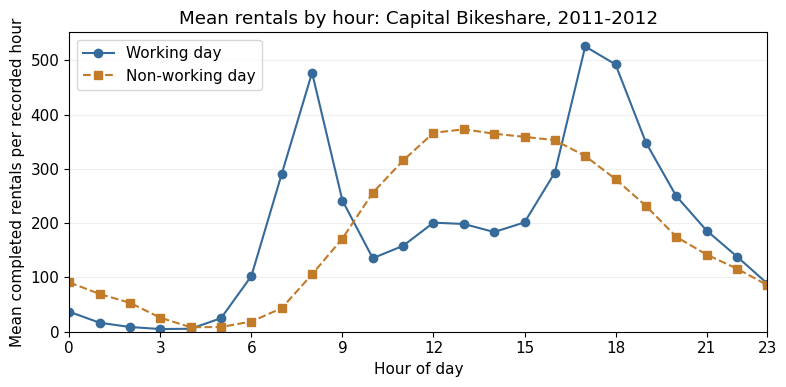

In [13]:
hourly_means = df.groupby(["hr", "workingday"])["cnt"].mean().unstack()
fig, ax = plt.subplots()
ax.plot(hourly_means.index, hourly_means[1], label="Working day", color="#356a9a", marker="o")
ax.plot(hourly_means.index, hourly_means[0], label="Non-working day", color="#c17b29", marker="s", linestyle="--")
ax.set(title="Mean rentals by hour: Capital Bikeshare, 2011-2012",
       xlabel="Hour of day", ylabel="Mean completed rentals per recorded hour",
       xticks=[0, 3, 6, 9, 12, 15, 18, 21, 23], xlim=(0, 23), ylim=(0, None))
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figures / "02_hour_workingday.png", dpi=160, bbox_inches="tight")
plt.show()

In [14]:
for workingday, label in [(1, "Working day"), (0, "Non-working day")]:
    peak_hour = int(hourly_means[workingday].idxmax())
    print(f"{label} peak: {peak_hour:02d}:00, mean {hourly_means.loc[peak_hour, workingday]:.2f}")

Working day peak: 17:00, mean 525.29
Non-working day peak: 13:00, mean 372.73


Working days show morning and late-afternoon peaks. Their highest mean is at 17:00 (525.29 rentals). Non-working days have a broader daytime peak, with the highest mean at 13:00 (372.73 rentals). These are observed patterns, not evidence of why people rented bikes.

### 6.2 Working Day vs Non-working Day

In [15]:
workingday_statistics = df.groupby("workingday")["cnt"].agg(["count", "mean", "median", "std"])
display(workingday_statistics.round(2))

,count,mean,median,std
workingday,,,,
0,5514,181.41,119.0,172.85
1,11865,193.21,151.0,185.11


The overall hourly mean is 193.21 on working days and 181.41 on non-working days. Figure 2 also shows that their hourly patterns differ. In the README, a working day is neither a weekend nor a holiday.

### 6.3 Rentals by Weather

The labels below shorten the weather categories in the official README. The counts show how many recorded hours contribute to each average.

In [16]:
weather_statistics = df.groupby("weathersit")["cnt"].agg(["count", "mean", "median", "std"])
display(weather_statistics.round(2))

,count,mean,median,std
weathersit,,,,
1,11413,204.87,159.0,189.49
2,4544,175.17,133.0,165.43
3,1419,111.58,63.0,133.78
4,3,74.33,36.0,77.93


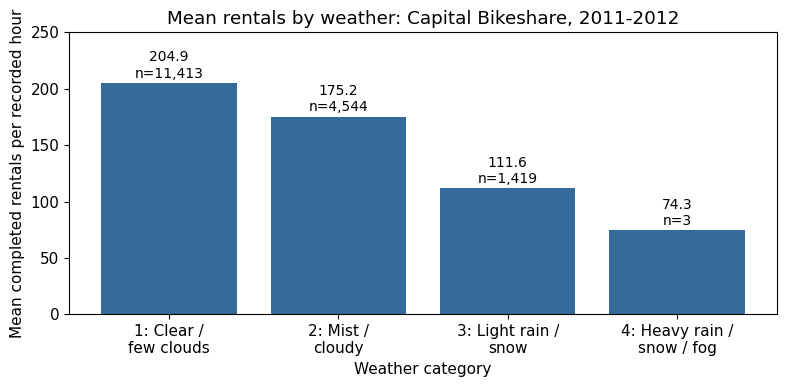

In [17]:
weather_labels = ["1: Clear /\nfew clouds", "2: Mist /\ncloudy", "3: Light rain /\nsnow", "4: Heavy rain /\nsnow / fog"]
fig, ax = plt.subplots()
ax.bar(range(4), weather_statistics["mean"], color="#356a9a")
ax.set(title="Mean rentals by weather: Capital Bikeshare, 2011-2012",
       xlabel="Weather category", ylabel="Mean completed rentals per recorded hour",
       xticks=range(4), xticklabels=weather_labels, ylim=(0, 250))
for position, row in enumerate(weather_statistics.itertuples()):
    ax.text(position, row.mean + 5, f"{row.mean:.1f}\nn={int(row.count):,}", ha="center", fontsize=10)
fig.tight_layout()
fig.savefig(figures / "03_weather.png", dpi=160, bbox_inches="tight")
plt.show()

The mean is 204.87 rentals per hour in clear/few-cloud weather and 111.58 in light rain/snow. Weather category 4 has only three records, so its average should be read cautiously. These group averages are associations and do not show a weather effect.

## 7. Bias and Measurement Limitations

1. The data come from Capital Bikeshare, so other systems may have different patterns.
2. The data cover only 2011-2012, so current rental patterns may be different.
3. Weather and rentals have an observational association. Season, time of day, and working-day status may also affect the patterns.

**Measurement counterexample:** Suppose 200 people want to rent a bike, but only 100 bikes are available. In a simple example where each available bike is rented once, the dataset would record about 100 completed rentals rather than all 200 people who wanted a bike. Therefore, `cnt` measures completed rentals, not perfect latent demand.

**This is a conceptual example, not an observed event in the dataset.**

## 8. Prohibited Claims

- We should not claim that weather causes changes in bike rental demand based only on this observational dataset.
- We should not assume that the results apply to all cities, all bike-sharing systems, or current users.

## 9. Conclusion

The basic checks found no missing values, duplicate rows, duplicate date-hour keys, invalid values in the checked ranges, or count-identity failures. The schema matches the expected fields and types. Inspecting large counts did not provide a reason to remove them.

Rental patterns differ by hour, working-day status, and weather category. The averages describe this dataset. They should not be interpreted as causal effects, and completed rentals do not measure all demand.

## 10. AI Use and Reproducibility

OpenAI Codex / ChatGPT helped organize the project, write and check code, and improve explanations and figures. The notebook was rerun in a fresh kernel, and the main results were checked against the raw CSV. Dataset information was checked against UCI and the supplied README. This does not claim that the student personally performed those checks. Details are in `docs/ai_use_log.md`.

To run: install `requirements.txt`, open this notebook in Jupyter, and choose **Restart Kernel -> Run All**. No credentials or network access are needed to analyze the included CSV. The notebook writes two result tables and three figure files. The PDF is a saved report; PDF-generation tools are not notebook dependencies.

Repository: [https://github.com/Zhoujie-SONG/DS-A1-bike-sharing-audit](https://github.com/Zhoujie-SONG/DS-A1-bike-sharing-audit).